In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('~/workspace/sidu/musimpanas/hard_dataset.csv')

In [4]:
df.head()

,x,y,label
0,0.471969,0.290023,0
1,-0.647295,-0.637178,0
2,-0.551973,-1.019000,0
3,-0.150224,0.636008,0
4,-0.335839,0.642716,0


In [5]:
import seaborn as sns

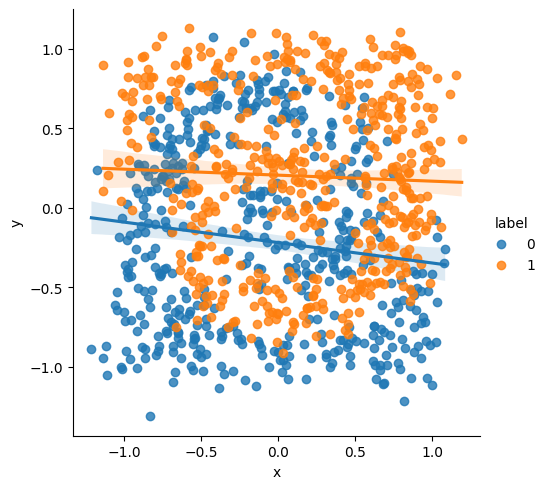

In [9]:
sns.lmplot(x='x', y='y', data=df, hue='label')

In [ ]:
import numpy as np
from scipy.spatial import Voronoi
import pandas as pd
from shapely.ops import orient
from shapely import geometry
import shapely
import altair as alt

# make up data points add 4 distant dummy points and compute Voronoi tesselation
from scipy.spatial import Voronoi  # Import the Voronoi algorithm from SciPy
import pandas as pd  # Import Pandas for data manipulation and analysis
from shapely.ops import orient  # Import Orient function from Shapely library
from shapely import geometry  # Import Geometry module from Shapely library
import shapely  # Import Shapely library for geometric computations
import altair as alt  # Import Altair library for data visualization

# Create a sample dataset of points with 'u', 'v', and 'z' coordinates
df_pts = pd.DataFrame(
    {"u": [0.1, 0.9, 0.1, 0.9, 0.5], "v": [0.1, 0.1, 0.9, 0.9, 0.5], "z": list("abcde")}
    {"u": [0.1, 0.9, 0.1, 0.9, 0.5],  # Define x-coordinates for the points
     "v": [0.1, 0.1, 0.9, 0.9, 0.5],  # Define y-coordinates for the points
     "z": list("abcde")  # Assign unique 'z' values to each point
}
)

# Extend the original dataset by adding four distant dummy points and compute Voronoi tesselation
df_pts_extended = pd.concat(
    (
        df_pts,
        pd.DataFrame(
            [[999, 999], [-999, 999], [999, -999], [-999, -999]], columns=["u", "v"]
        df_pts,  # Add original points to new DataFrame
        pd.DataFrame(  # Create a new DataFrame with dummy points
            [[999, 999], [-999, 999], [999, -999], [-999, -999]],  # Define coordinates for dummy points
            columns=["u", "v"]  # Specify column names for the dummy points
        ),
    ),
    ignore_index=True,
)
points = df_pts_extended[["u", "v"]].values
points = df_pts_extended[["u", "v"]].values  # Get 'u' and 'v' values from extended DataFrame

# Compute Voronoi diagram using SciPy's Voronoi function
vor = Voronoi(points)

# polygonize voronoi regions as geojson features, add 'tessel' index key for color
# Iterate through each Voronoi region, create a polygon, and convert it to GeoJSON feature
vals = []
for ix, region in enumerate(vor.regions):
    if not -1 in region:
        polygon = [vor.vertices[i] for i in region]
        geompol = geometry.Polygon(polygon)
        if not geompol.is_empty:
            if geompol.exterior.is_ccw:
                geompol = orient(geompol, -1)
    if not -1 in region:  # Check if the region is valid (i.e., not empty)
        polygon = [vor.vertices[i] for i in region]  # Extract vertices from region
        geompol = geometry.Polygon(polygon)  # Create Shapely Polygon object
        if not geompol.is_empty:  # Check if polygon is valid
            if geompol.exterior.is_ccw:  # Check if exterior orientation of polygon is clockwise
                geompol = orient(geompol, -1)  # Orient the polygon to make its exterior counterclockwise
            feature = {
                "type": "Feature",
                "properties": {},
                "geometry": shapely.geometry.mapping(geompol),
                "type": "Feature",  # Define GeoJSON feature type
                "properties": {},  # Initialize properties dictionary for feature
                "geometry": shapely.geometry.mapping(geompol),  # Convert Shapely Polygon object to GeoJSON geometry
            }
            ixs=vor.point_region[ix-1]  # trial
            ixs = vor.point_region[ix - 1]  # Get index of point associated with current region
            vals.append({
                "geo": feature,
                "tessel": df_pts_extended.iloc[ixs].z  # trial
                "geo": feature,  # Add GeoJSON feature to list
                "tessel": df_pts_extended.iloc[ixs].z  # Assign 'z' value from original DataFrame to feature
            })

# set the fit/extent range of axes, must be an array with a geom
xmin, xmax = 0, 1
ymin, ymax = 0, 1
# Set the fit/extent range of axes, which must be an array with a geometry
xmin, xmax = 0, 1  # Define x-coordinate range for extent
ymin, ymax = 0, 1  # Define y-coordinate range for extent
extent = geometry.Polygon(
    [(xmax, ymax), (xmax, ymin), (xmin, ymin), (xmin, ymax), (xmax, ymax)]
    [(xmax, ymax), (xmax, ymin), (xmin, ymin), (xmin, ymax), (xmax, ymax)]  # Define coordinates for extent
)
fit = [shapely.geometry.mapping(extent)]

voronoi = alt.Data(name="vals", values=vals)
fit = [shapely.geometry.mapping(extent)]  # Convert Shapely Polygon object to GeoJSON feature and add it to list

# Create an Altair chart with the computed Voronoi regions and original points
voronoi = alt.Data(name="vals", values=vals)  # Create a data source for the chart from the 'vals' list
c_vor = (
    alt.Chart(voronoi)
    .mark_geoshape(clip=True, tooltip=True, opacity=0.3, stroke="black")
    .encode(shape="geo:G", color="tessel:N")
    .mark_geoshape(clip=True, tooltip=True, opacity=0.3, stroke="black")  # Style and mark Voronoi regions as geoshapes
    .encode(shape="geo:G", color="tessel:N")  # Map 'geo' field to shape and 'tessel' field to color
)

# Create an Altair chart with the original points
c_pts = (
    alt.Chart(df_pts)
    .mark_circle(clip=True, color="orange", tooltip=True, size=100, opacity=1)
    .encode(latitude="u:Q", longitude="v:Q", color="z:N")
    .mark_circle(clip=True, color="orange", tooltip=True, size=100, opacity=1)  # Style and mark original points as circles
    .encode(latitude="u:Q", longitude="v:Q", color="z:N")  # Map 'u' field to latitude, 'v' field to longitude, and 'z' field to color
)

# Combine the two charts and project them using Altair's project function
(c_vor + c_pts).project(
    type="identity", reflectY=True, fit=fit
    type="identity", reflectY=True, fit=fit  # Set chart projection parameters (identity transformation, reflect Y-axis, fit extent)
)

SchemaValidationError: 'Polygon' is an invalid value for `type`.

'Feature' was expected
'FeatureCollection' was expected